<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/SVM%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  
0          0.11840           0.27760          0.3001              0.14710  
1          0.08474           0.07864          0.0869              0.07017  
2          0.10960           0.15990          0.1974              0.12790  
3          0.14250           0.28390          0.2414              0.10520  
4          0.10030           0.13280          0.1980              0.10430  

Dataset Shape:
(569, 10)

Column Names:
Index(['id', '

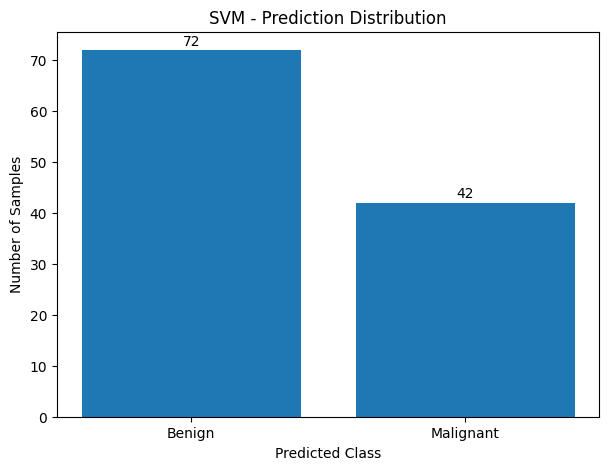

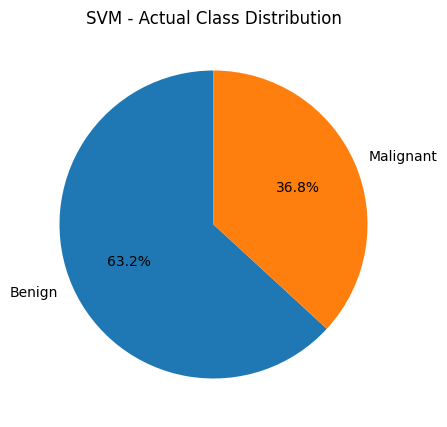

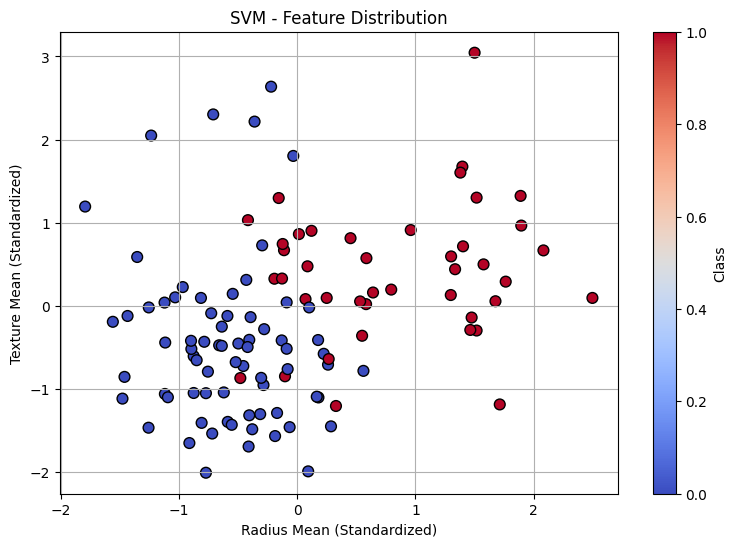


           FINAL RESULT
SVM Accuracy = 96.49%


In [3]:
# ============================================================
# SVM MODEL - BREAST CANCER WISCONSIN DATASET
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

# Upload data.csv to Google Colab first

df = pd.read_csv("data-selected-columns.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)


# ------------------------------------------------------------
# 3. REMOVE UNNECESSARY COLUMNS
# ------------------------------------------------------------

# Remove ID column
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Remove Unnamed column
if "Unnamed: 32" in df.columns:
    df = df.drop("Unnamed: 32", axis=1)


# ------------------------------------------------------------
# 4. CONVERT TARGET VALUES
# ------------------------------------------------------------

# M = Malignant
# B = Benign

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})


# ------------------------------------------------------------
# 5. SEPARATE INPUT AND OUTPUT
# ------------------------------------------------------------

X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]


print("\nInput Features:")
print(X.shape)

print("\nTarget:")
print(y.shape)


# ------------------------------------------------------------
# 6. SPLIT DATASET
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 7. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ------------------------------------------------------------
# 8. CREATE SVM MODEL
# ------------------------------------------------------------

model = SVC(
    kernel="rbf",
    random_state=42
)


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

model.fit(X_train, y_train)


# ------------------------------------------------------------
# 10. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 11. CALCULATE ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("           SVM RESULTS")
print("======================================")

print("Accuracy:", accuracy)

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)


# ------------------------------------------------------------
# 12. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)


# ============================================================
# GRAPH 1 - PREDICTION DISTRIBUTION
# ============================================================

prediction_counts = pd.Series(
    y_pred
).value_counts().sort_index()


plt.figure(figsize=(7, 5))

plt.bar(
    ["Benign", "Malignant"],
    prediction_counts.values
)

plt.xlabel("Predicted Class")

plt.ylabel("Number of Samples")

plt.title(
    "SVM - Prediction Distribution"
)

# Display values on bars
for i, value in enumerate(
    prediction_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()


# ============================================================
# GRAPH 2 - ACTUAL CLASS DISTRIBUTION
# ============================================================

actual_counts = pd.Series(
    y_test
).value_counts().sort_index()


plt.figure(figsize=(7, 5))

plt.pie(
    actual_counts.values,
    labels=[
        "Benign",
        "Malignant"
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "SVM - Actual Class Distribution"
)

plt.show()


# ============================================================
# GRAPH 3 - SVM FEATURE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))


# Feature 1 = radius_mean
# Feature 2 = texture_mean

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="coolwarm",
    s=60,
    edgecolors="black"
)


plt.xlabel(
    "Radius Mean (Standardized)"
)

plt.ylabel(
    "Texture Mean (Standardized)"
)

plt.title(
    "SVM - Feature Distribution"
)


plt.colorbar(
    label="Class"
)

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"SVM Accuracy = {accuracy * 100:.2f}%"
)

